# Hyperion Economy Simulation Notebook

Dieses Notebook nutzt die vollständige Hyperion-Ökonomielogik aus `trade_sim.py` und führt eine **nicht-interaktive Mehrjahres-Simulation** aus.

Ablauf:
1. Parameter in einer Zelle setzen
2. Simulation über festgelegte Perioden/Jahre laufen lassen
3. Ergebnisse als **Pandas-Tabellen** und **Matplotlib-Grafiken** ausgeben


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

from trade_sim import HyperionEconomySim, SimulationConfig, GOODS

plt.style.use('ggplot')


## 1) Parameter
Passe diese Werte an und führe die Zelle aus.


In [2]:
# Simulationsparameter
YEARS = 30
SEED = 7
NUM_RUNS = 5
EVENT_CHANCE = 0.45
TRADE_INTENSITY = 1.0
FACTION_STRENGTH = 1.0

TOP_N_WORLDS = 5
SHOW_TRADE_LOG_PER_YEAR = 3  # Einträge pro Jahr in der Jahrestabelle

if not isinstance(YEARS, int) or YEARS <= 0:
    raise ValueError('YEARS muss eine positive ganze Zahl sein.')
if not isinstance(NUM_RUNS, int) or NUM_RUNS <= 0:
    raise ValueError('NUM_RUNS muss eine positive ganze Zahl sein.')
for name, value in {
    'EVENT_CHANCE': EVENT_CHANCE,
    'TRADE_INTENSITY': TRADE_INTENSITY,
    'FACTION_STRENGTH': FACTION_STRENGTH,
}.items():
    if not 0 <= value <= 1.5:
        raise ValueError(f'{name} muss zwischen 0 und 1.5 liegen.')

RUN_SEEDS = [SEED + run for run in range(NUM_RUNS)]
print(f'{NUM_RUNS} Läufe mit Seeds: {RUN_SEEDS}')


5 Läufe mit Seeds: [7, 8, 9, 10, 11]


## 2) Simulation ausführen


In [3]:
config = SimulationConfig(
    ticks=YEARS,
    seed=SEED,
    event_chance=EVENT_CHANCE,
    trade_intensity=TRADE_INTENSITY,
    faction_strength=FACTION_STRENGTH,
)
sim = HyperionEconomySim(config)

yearly_rows = []
world_rows = []
price_rows = []
event_rows = []

for run, run_seed in enumerate(RUN_SEEDS, start=1):
    config = SimulationConfig(
        ticks=YEARS,
        seed=run_seed,
        event_chance=EVENT_CHANCE,
        trade_intensity=TRADE_INTENSITY,
        faction_strength=FACTION_STRENGTH,
    )
    sim = HyperionEconomySim(config)

    for _ in range(YEARS):
        sim.step()
        event_types = [
            event.strip() for event in sim.current_events
            if event and event.strip()
        ]

        yearly_rows.append({
            'run': run,
            'seed': run_seed,
            'year': sim.tick,
            'events': '; '.join(event_types) if event_types else 'keine',
            'event_count': len(event_types),
            'core_signal': sim.faction_state['core_signal'],
            'ouster_threat': sim.faction_state['ouster_threat'],
            'templar_access': sim.faction_state['templar_access'],
            'trade_log_excerpt': ' | '.join(
                sim.trade_log[:SHOW_TRADE_LOG_PER_YEAR]
            ) if sim.trade_log else 'kein Handel',
        })

        for event_type in event_types:
            event_rows.append({
                'run': run,
                'year': sim.tick,
                'event_type': event_type,
            })

        for w in sim.worlds:
            world_rows.append({
                'run': run,
                'seed': run_seed,
                'year': sim.tick,
                'world': w.name,
                'category': w.category,
                'faction': w.faction,
                'farcaster': w.farcaster,
                'periphery': w.periphery,
                'stability': w.stability,
                'prosperity': w.prosperity,
                'time_debt': w.time_debt,
                'hyperion_special': w.hyperion_special,
            })
            for good in GOODS:
                price_rows.append({
                    'run': run,
                    'year': sim.tick,
                    'world': w.name,
                    'good': good,
                    'price': w.prices[good],
                    'stock': w.stock[good],
                })

df_yearly = pd.DataFrame(yearly_rows)
df_world = pd.DataFrame(world_rows)
df_price = pd.DataFrame(price_rows)
df_events = pd.DataFrame(event_rows)

print(f'Fertig. {NUM_RUNS} Läufe mit jeweils {YEARS} Jahren simuliert.')
print(
    f'Datensätze: yearly={len(df_yearly)}, world={len(df_world)}, '
    f'price={len(df_price)}, events={len(df_events)}'
)


Fertig. 5 Läufe mit jeweils 30 Jahren simuliert.
Datensätze: yearly=150, world=1200, price=9600, events=61


## 3) Tabellen-Auswertung


In [4]:
# Jahresüberblick
df_yearly.head(10)

# Zentrale Kennzahlen je Lauf
run_kpis = (
    df_world.groupby('run', as_index=False)
    .agg(
        mean_prosperity=('prosperity', 'mean'),
        final_prosperity=('prosperity', lambda s: s.iloc[-1]),
        mean_stability=('stability', 'mean'),
        min_stability=('stability', 'min'),
        max_time_debt=('time_debt', 'max'),
        mean_time_debt=('time_debt', 'mean'),
    )
)
run_kpis['price_volatility'] = (
    df_price.groupby('run')['price']
    .std()
    .reindex(run_kpis['run'])
    .to_numpy()
)
run_kpis

# Ereignishäufigkeit und Ereigniswirkung im Folgejahr
if df_events.empty:
    event_frequency = pd.DataFrame(
        {'event_type': pd.Series(dtype='object'),
         'count': pd.Series(dtype='int64')}
    )
else:
    event_frequency = (
        df_events['event_type'].value_counts()
        .rename_axis('event_type')
        .reset_index(name='count')
    )
event_frequency

if not df_events.empty:
    prosperity_by_run_year = (
        df_world.groupby(['run', 'year'], as_index=False)
        .agg(avg_prosperity=('prosperity', 'mean'))
    )
    event_impact = df_events.merge(
        prosperity_by_run_year,
        on=['run', 'year'],
        how='left',
    ).rename(columns={'avg_prosperity': 'event_year_prosperity'})
    next_year = prosperity_by_run_year.rename(
        columns={
            'year': 'next_year',
            'avg_prosperity': 'next_year_prosperity',
        }
    )
    event_impact['next_year'] = event_impact['year'] + 1
    event_impact = event_impact.merge(
        next_year,
        on=['run', 'next_year'],
        how='left',
    )
    event_impact['prosperity_change_next_year'] = (
        event_impact['next_year_prosperity']
        - event_impact['event_year_prosperity']
    )
    event_impact_summary = (
        event_impact.groupby('event_type', as_index=False)
        .agg(
            occurrences=('event_type', 'size'),
            mean_next_year_change=(
                'prosperity_change_next_year', 'mean'
            ),
        )
        .sort_values('occurrences', ascending=False)
    )
    event_impact_summary

## 6) Automatische Tests

from pathlib import Path

# Grundstruktur der Simulation
assert YEARS > 0
assert NUM_RUNS > 0
assert RUN_SEEDS == [SEED + i for i in range(NUM_RUNS)]
assert set(df_yearly['run']) == set(range(1, NUM_RUNS + 1))
assert set(df_world['run']) == set(range(1, NUM_RUNS + 1))
assert set(df_price['run']) == set(range(1, NUM_RUNS + 1))

# Erwartete Zeitachsen und Fremdschlüssel
assert df_yearly['year'].between(1, YEARS).all()
assert df_world['year'].between(1, YEARS).all()
assert df_price['year'].between(1, YEARS).all()
assert df_world[['run', 'year', 'world']].drop_duplicates().shape[0] == len(df_world)
assert df_price[['run', 'year', 'world', 'good']].drop_duplicates().shape[0] == len(df_price)

# Keine fehlenden Kernwerte
for frame, columns in (
    (df_yearly, ['run', 'year']),
    (df_world, ['run', 'year', 'world', 'prosperity', 'stability']),
    (df_price, ['run', 'year', 'world', 'good', 'price', 'stock']),
):
    assert not frame[columns].isna().any().any(), f'Fehlende Werte in {columns}'

# Ereignistabelle darf auch leer sein, muss aber die erwarteten Spalten besitzen
assert list(df_events.columns) == ['run', 'year', 'event_type'] or df_events.empty
if not df_events.empty:
    assert df_events['event_type'].notna().all()
    assert df_events['year'].between(1, YEARS).all()

# Auswertungen wurden erzeugt
assert len(run_kpis) == NUM_RUNS
assert not df_price.empty
price_summary_for_test = (
    df_price.groupby(['year', 'good'], as_index=False)
    .agg(avg_price=('price', 'mean'))
)
assert len(price_summary_for_test) > 0
assert set(run_kpis['run']) == set(range(1, NUM_RUNS + 1))

# Exporte vor der Dateiprüfung erzeugen
df_yearly.to_csv('hyperion_yearly.csv', index=False)
df_world.to_csv('hyperion_world.csv', index=False)
df_price.to_csv('hyperion_price.csv', index=False)
df_events.to_csv('hyperion_events.csv', index=False)
run_kpis.to_csv('hyperion_kpis.csv', index=False)

df_yearly.to_parquet('hyperion_yearly.parquet', index=False)
df_world.to_parquet('hyperion_world.parquet', index=False)
df_price.to_parquet('hyperion_price.parquet', index=False)

simulation_metadata = {
    'years': YEARS,
    'base_seed': SEED,
    'run_seeds': RUN_SEEDS,
    'num_runs': NUM_RUNS,
    'event_chance': EVENT_CHANCE,
    'trade_intensity': TRADE_INTENSITY,
    'faction_strength': FACTION_STRENGTH,
}
with open('hyperion_simulation_config.json', 'w', encoding='utf-8') as file:
    json.dump(simulation_metadata, file, ensure_ascii=False, indent=2)

# Exportdateien vorhanden
export_files = [
    'hyperion_yearly.csv',
    'hyperion_world.csv',
    'hyperion_price.csv',
    'hyperion_events.csv',
    'hyperion_kpis.csv',
    'hyperion_yearly.parquet',
    'hyperion_world.parquet',
    'hyperion_price.parquet',
    'hyperion_simulation_config.json',
]
missing_exports = [name for name in export_files if not Path(name).is_file()]
assert not missing_exports, f'Fehlende Exportdateien: {missing_exports}'

print('Alle Tests erfolgreich.')


Alle Tests erfolgreich.


In [5]:
# Letztes Simulationsjahr: Top-Welten nach Wohlstand
last_year = df_world['year'].max()
top_worlds_last = (
    df_world[df_world['year'] == last_year]
    .sort_values(['prosperity', 'stability'], ascending=False)
    .head(TOP_N_WORLDS)
)
top_worlds_last


,run,seed,year,world,category,faction,farcaster,periphery,stability,prosperity,time_debt,hyperion_special
955,4,10,30,Marsim,Industriewelt,Hegemonie,True,False,0.619497,1.369070,27.799151,False
717,3,9,30,Bressia,Grenzwelt,Hegemonie,False,True,0.377563,1.353809,22.440172,False
713,3,9,30,Tau Ceti,Agrarwelt,Hegemonie,True,False,0.729178,1.338847,6.322874,False
235,1,7,30,Marsim,Industriewelt,Hegemonie,True,False,0.638324,1.336457,29.813603,False
957,4,10,30,Bressia,Grenzwelt,Hegemonie,False,True,0.389451,1.335370,21.501008,False


In [6]:
# Durchschnittspreise pro Gut und Jahr über alle Welten
df_price_avg = (
    df_price.groupby(['run', 'year', 'good'], as_index=False)
    .agg(avg_price=('price', 'mean'), avg_stock=('stock', 'mean'))
)
df_price_avg.head(12)

# Mittelwerte und Streuung über alle Läufe
df_price_summary = (
    df_price.groupby(['year', 'good'], as_index=False)
    .agg(
        avg_price=('price', 'mean'),
        price_std=('price', 'std'),
        avg_stock=('stock', 'mean'),
    )
)
df_price_summary.head(12)


,year,good,avg_price,price_std,avg_stock
0,1,biotech,83.34975,3.226512,28.057214
1,1,core_daten,112.06475,4.971496,28.613878
2,1,energie,38.11775,1.671892,26.651284
3,1,industrieteile,42.75425,2.040744,27.852146
4,1,luxus,77.78500,3.518637,28.152283
5,1,nahrung,21.11875,0.958332,26.543066
6,1,relikte,143.41100,6.452585,27.836374
7,1,rohstoffe,28.51175,1.435875,27.571026
8,2,biotech,81.69525,3.786466,28.364429
9,2,core_daten,112.96475,5.568354,29.477757


In [7]:
# Hyperion-Fokus: Preise und Lager auf Hyperion
df_hyperion = df_price[df_price['world'] == 'Hyperion'].copy()
df_hyperion.head(12)


,run,year,world,good,price,stock
56,1,1,Hyperion,nahrung,22.13,22.5600
57,1,1,Hyperion,rohstoffe,28.89,25.4336
58,1,1,Hyperion,industrieteile,45.88,24.0000
59,1,1,Hyperion,energie,36.83,22.3200
60,1,1,Hyperion,luxus,83.51,22.4320
61,1,1,Hyperion,biotech,83.38,24.0000
62,1,1,Hyperion,core_daten,114.67,24.0000
63,1,1,Hyperion,relikte,144.42,24.7168
120,1,2,Hyperion,nahrung,21.62,21.1200
121,1,2,Hyperion,rohstoffe,26.08,26.8672


## 4) Grafiken


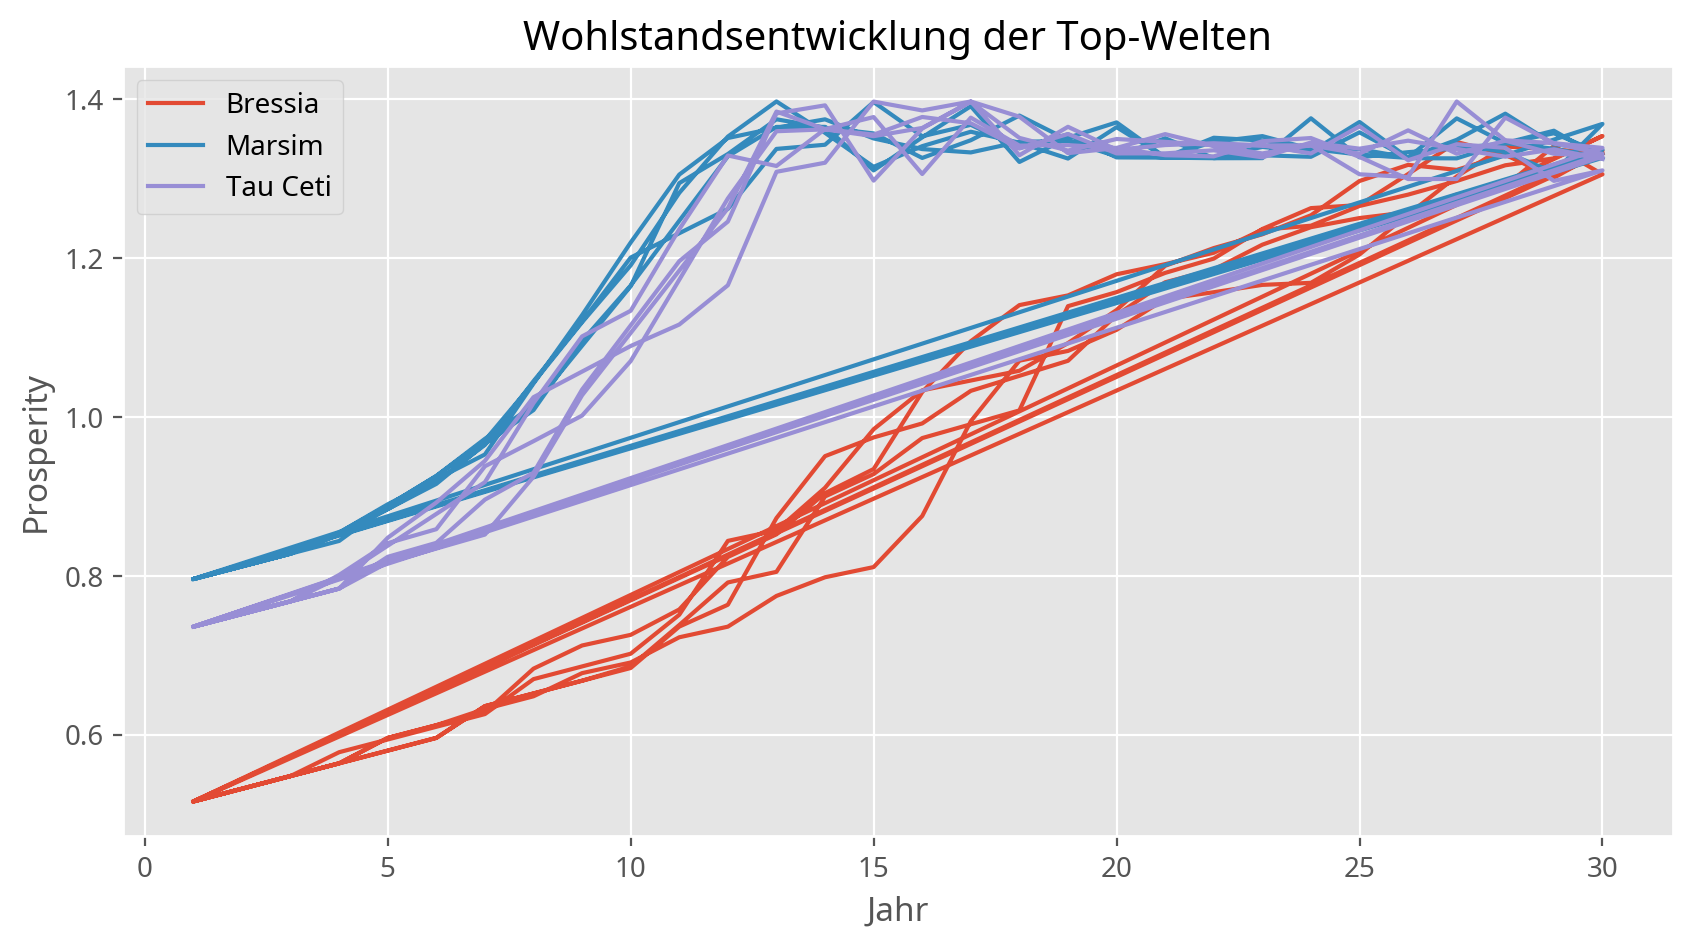

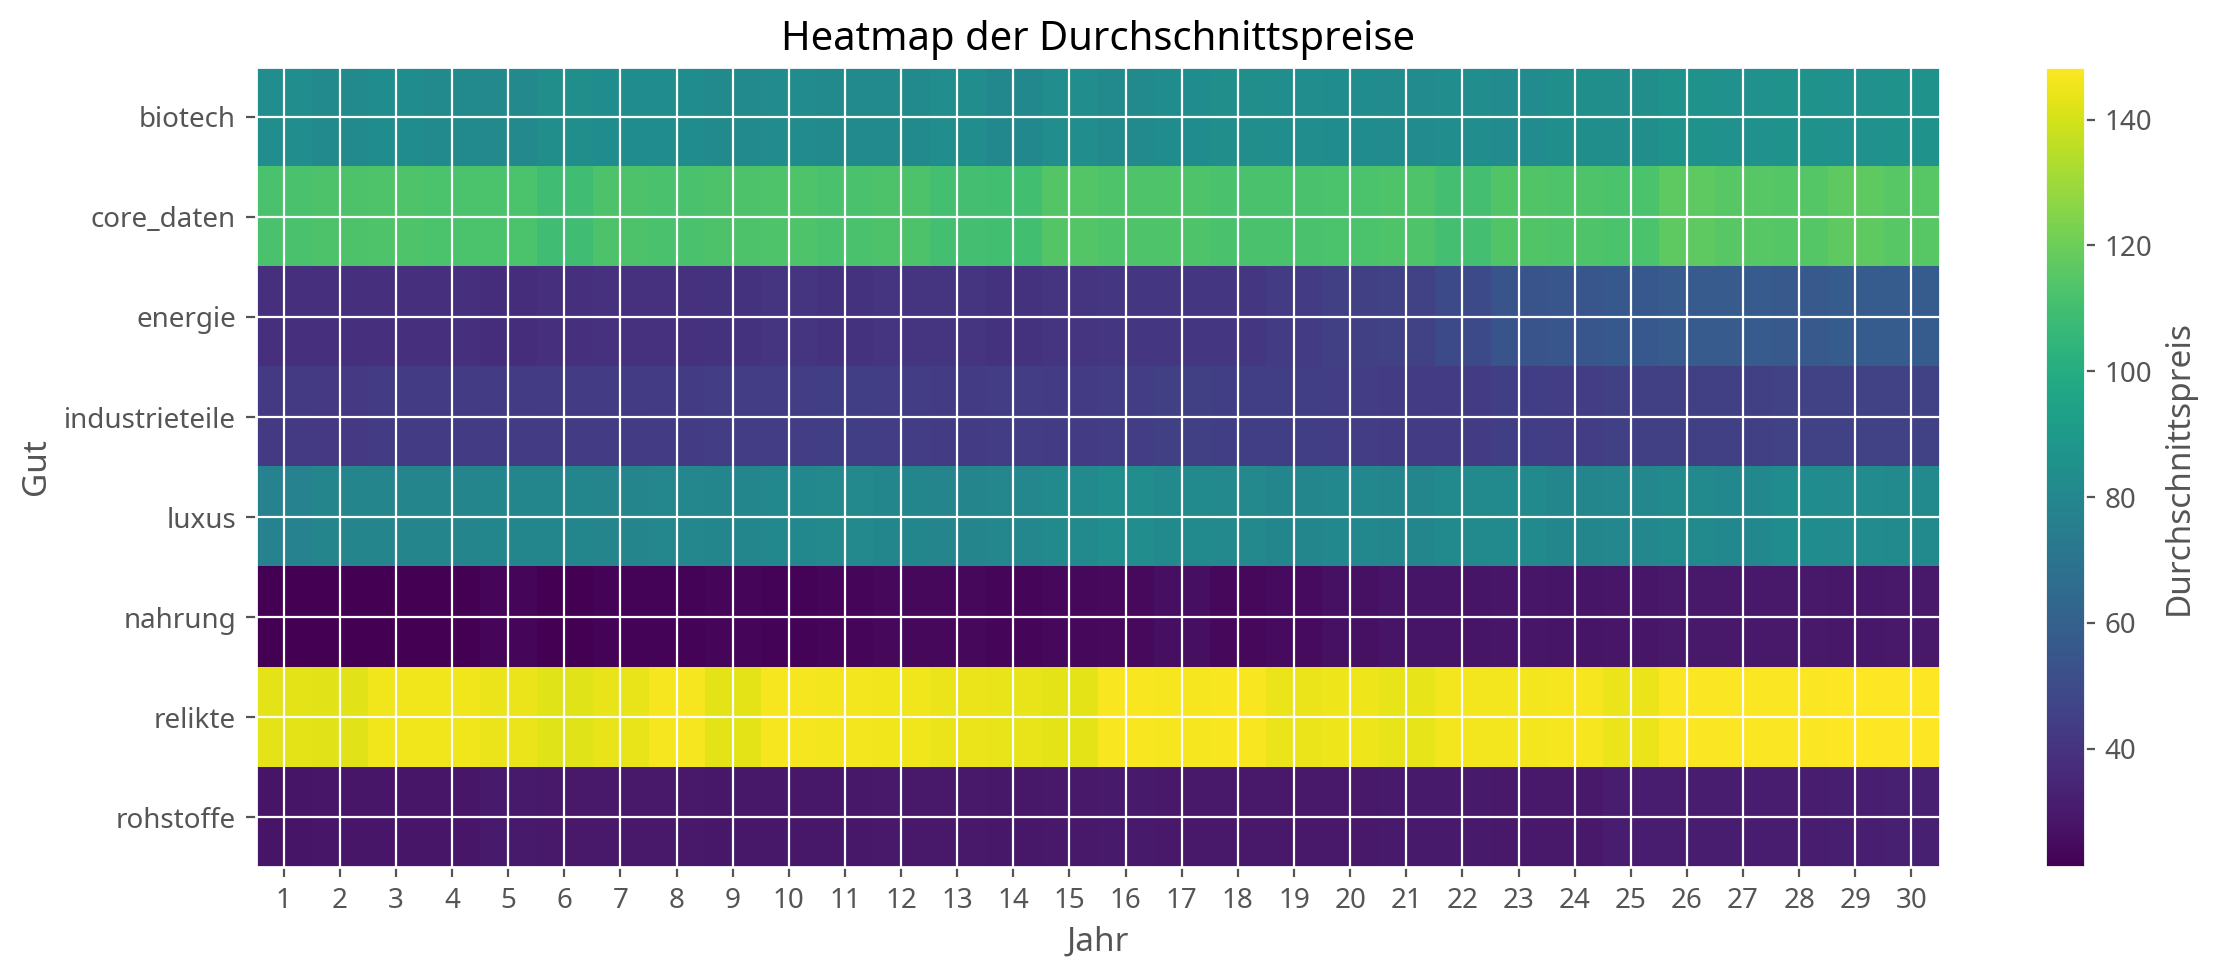

In [8]:
# 4.1 Wohlstandsentwicklung der Top-Welten (letztes Jahr)
top_world_names = top_worlds_last['world'].tolist()
plot_df = df_world[df_world['world'].isin(top_world_names)]

fig, ax = plt.subplots(figsize=(10, 5))
for world_name, grp in plot_df.groupby('world'):
    ax.plot(grp['year'], grp['prosperity'], label=world_name)
ax.set_title('Wohlstandsentwicklung der Top-Welten')
ax.set_xlabel('Jahr')
ax.set_ylabel('Prosperity')
ax.legend()
plt.show()

# 4.2 Heatmap: Durchschnittspreise nach Gut und Jahr
price_heatmap = df_price_summary.pivot(
    index='good', columns='year', values='avg_price'
)
fig, ax = plt.subplots(figsize=(12, 5))
image = ax.imshow(price_heatmap, aspect='auto', cmap='viridis')
ax.set_title('Heatmap der Durchschnittspreise')
ax.set_xlabel('Jahr')
ax.set_ylabel('Gut')
ax.set_yticks(range(len(price_heatmap.index)))
ax.set_yticklabels(price_heatmap.index)
ax.set_xticks(range(len(price_heatmap.columns)))
ax.set_xticklabels(price_heatmap.columns)
fig.colorbar(image, ax=ax, label='Durchschnittspreis')
plt.tight_layout()
plt.show()


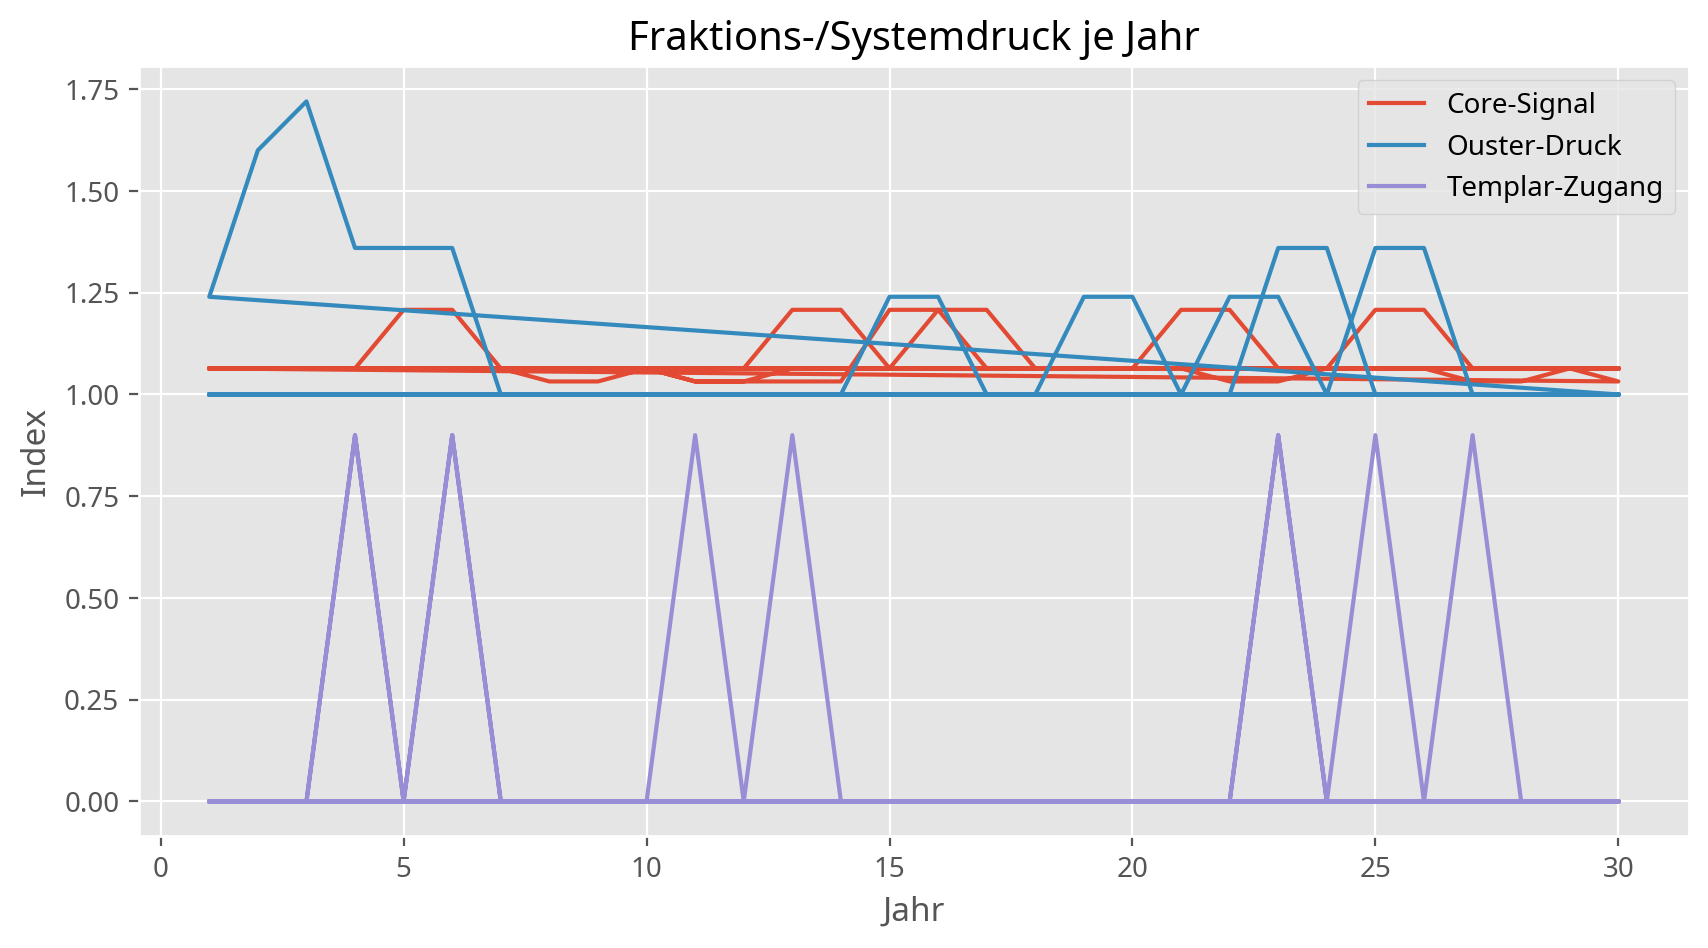

In [9]:
# 4.2 Fraktionsdruck über die Zeit
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_yearly['year'], df_yearly['core_signal'], label='Core-Signal')
ax.plot(df_yearly['year'], df_yearly['ouster_threat'], label='Ouster-Druck')
ax.plot(df_yearly['year'], df_yearly['templar_access'], label='Templar-Zugang')
ax.set_title('Fraktions-/Systemdruck je Jahr')
ax.set_xlabel('Jahr')
ax.set_ylabel('Index')
ax.legend()
plt.show()


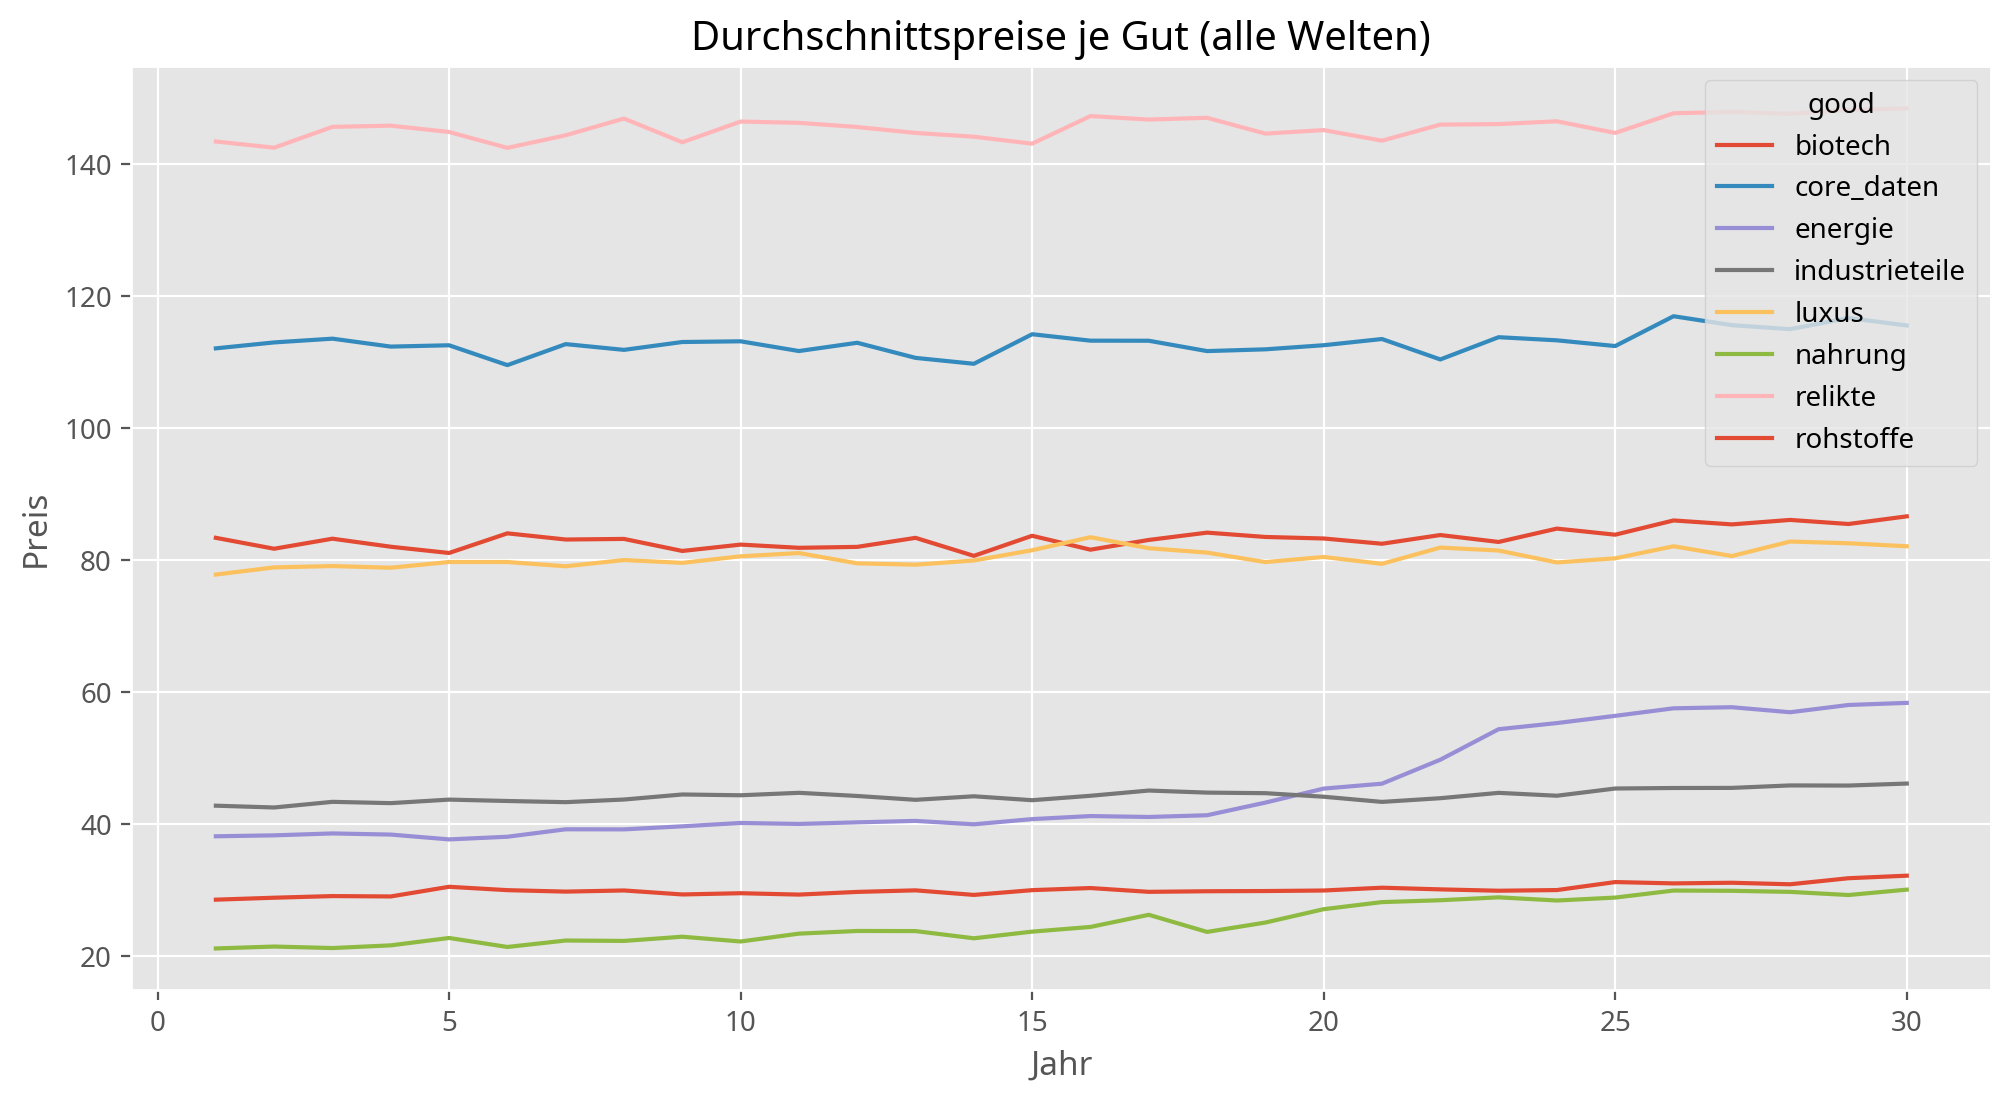

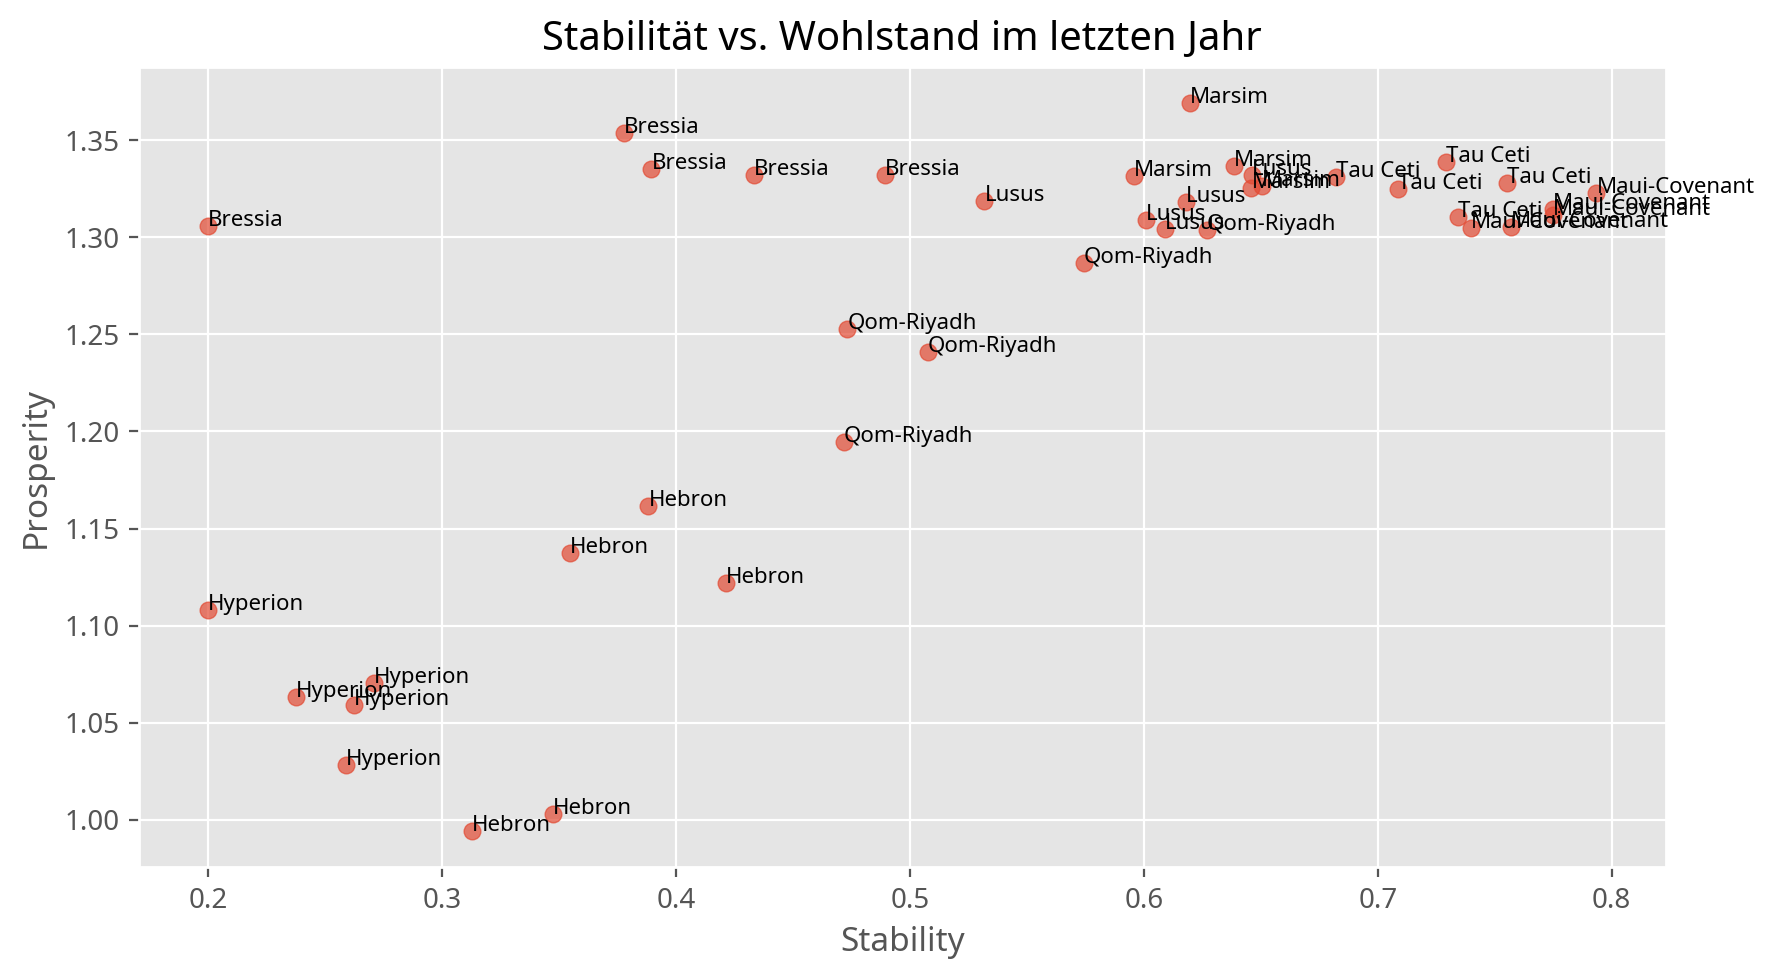

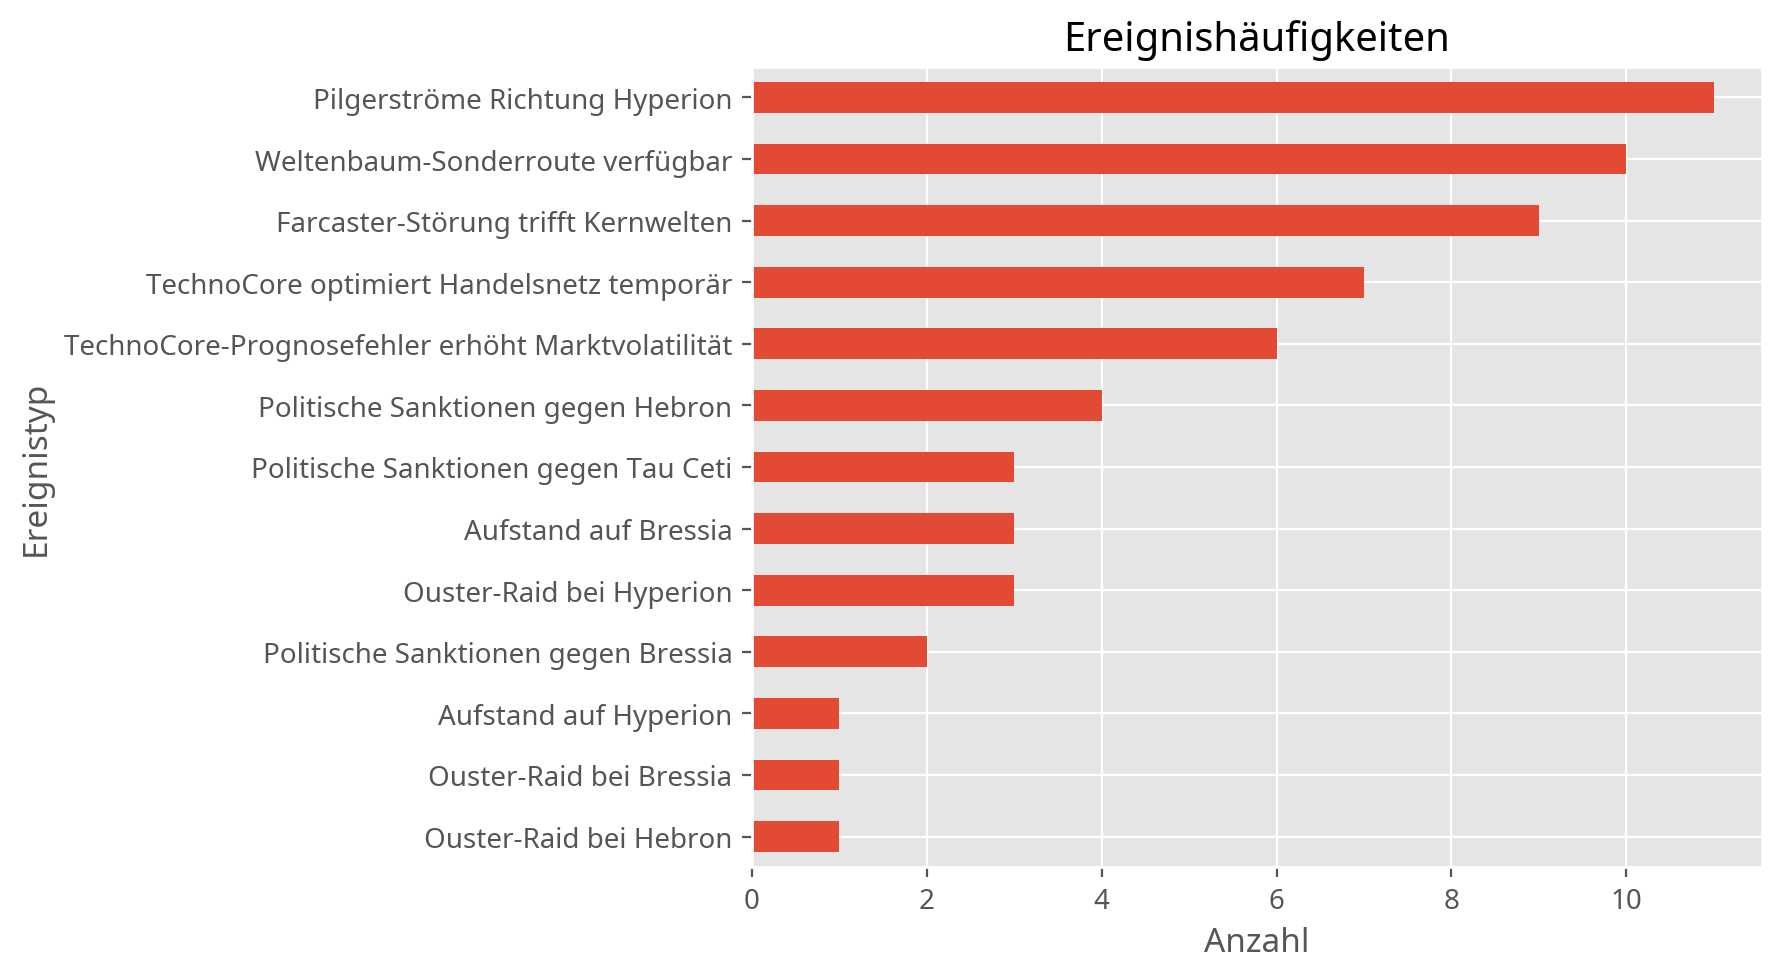

In [10]:
# 4.3 Durchschnittspreise pro Gut
fig, ax = plt.subplots(figsize=(12, 6))
pivot_prices = df_price_summary.pivot(
    index='year', columns='good', values='avg_price'
)
pivot_prices.plot(ax=ax)
ax.set_title('Durchschnittspreise je Gut (alle Welten)')
ax.set_xlabel('Jahr')
ax.set_ylabel('Preis')
plt.show()

# 4.5 Zusammenhang zwischen Stabilität und Wohlstand
latest_worlds = df_world[df_world['year'] == df_world['year'].max()]
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    latest_worlds['stability'],
    latest_worlds['prosperity'],
    alpha=0.7,
)
for _, row in latest_worlds.iterrows():
    ax.annotate(
        row['world'],
        (row['stability'], row['prosperity']),
        fontsize=8,
    )
ax.set_title('Stabilität vs. Wohlstand im letzten Jahr')
ax.set_xlabel('Stability')
ax.set_ylabel('Prosperity')
plt.tight_layout()
plt.show()

# 4.6 Ereignishäufigkeiten
if not event_frequency.empty:
    event_frequency.sort_values('count').plot.barh(
        x='event_type',
        y='count',
        legend=False,
        figsize=(9, 5),
        title='Ereignishäufigkeiten',
    )
    plt.xlabel('Anzahl')
    plt.ylabel('Ereignistyp')
    plt.tight_layout()
    plt.show()


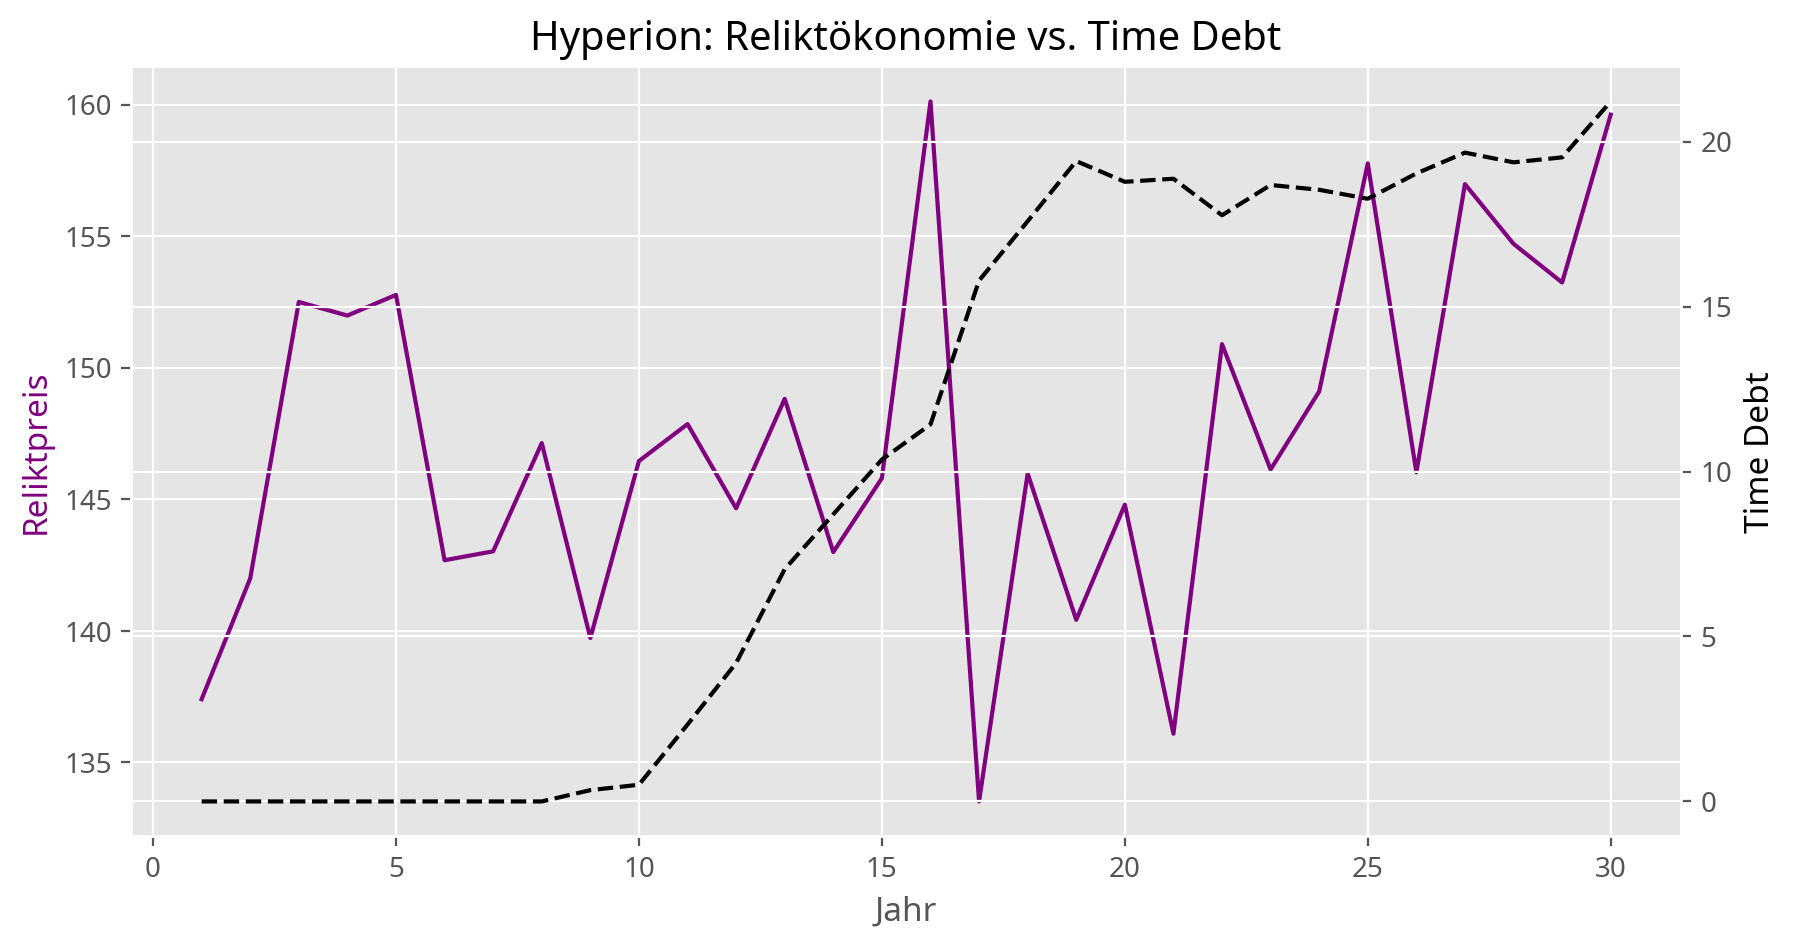

In [11]:
# 4.4 Hyperion-Sonderwelt: Reliktpreis + Time Debt
hyperion_world = df_world[df_world['world'] == 'Hyperion']
hyperion_relic = df_hyperion[df_hyperion['good'] == 'relikte']
hyperion_relic_avg = (
    hyperion_relic.groupby('year', as_index=False)
    .agg(price=('price', 'mean'))
)
hyperion_world_avg = (
    hyperion_world.groupby('year', as_index=False)
    .agg(time_debt=('time_debt', 'mean'))
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(
    hyperion_relic_avg['year'],
    hyperion_relic_avg['price'],
    color='purple',
    label='Reliktpreis Hyperion',
)
ax1.set_xlabel('Jahr')
ax1.set_ylabel('Reliktpreis', color='purple')

ax2 = ax1.twinx()
ax2.plot(
    hyperion_world_avg['year'],
    hyperion_world_avg['time_debt'],
    color='black',
    linestyle='--',
    label='Time Debt Hyperion',
)
ax2.set_ylabel('Time Debt', color='black')

ax1.set_title('Hyperion: Reliktökonomie vs. Time Debt')
plt.show()


## 5) Exportoption (optional)
Falls du die Daten weiter analysieren möchtest, kannst du sie als CSV speichern.


In [12]:
# CSV-Export
df_yearly.to_csv('hyperion_yearly.csv', index=False)
df_world.to_csv('hyperion_world.csv', index=False)
df_price.to_csv('hyperion_price.csv', index=False)
df_events.to_csv('hyperion_events.csv', index=False)
run_kpis.to_csv('hyperion_kpis.csv', index=False)

# Parquet-Export für kompakte Weiterverarbeitung
df_yearly.to_parquet('hyperion_yearly.parquet', index=False)
df_world.to_parquet('hyperion_world.parquet', index=False)
df_price.to_parquet('hyperion_price.parquet', index=False)

# Konfiguration gemeinsam mit den Ergebnissen speichern
simulation_metadata = {
    'years': YEARS,
    'base_seed': SEED,
    'run_seeds': RUN_SEEDS,
    'num_runs': NUM_RUNS,
    'event_chance': EVENT_CHANCE,
    'trade_intensity': TRADE_INTENSITY,
    'faction_strength': FACTION_STRENGTH,
}
with open('hyperion_simulation_config.json', 'w', encoding='utf-8') as file:
    json.dump(simulation_metadata, file, ensure_ascii=False, indent=2)

print('CSV-, Parquet- und JSON-Dateien wurden im aktuellen Arbeitsordner gespeichert.')


CSV-, Parquet- und JSON-Dateien wurden im aktuellen Arbeitsordner gespeichert.
